# 14 · Caso de estudio 2: el sistema de puntos de MiMcDonald's

En el Caso de Estudio 2 hicimos de consultores: McDonald's Guatemala tiene un programa de
puntos que **nadie documentó** y no nos dieron datos. Este notebook arma una **réplica en
miniatura** del caso, en pandas y en tu compu, para ver con números cada idea del tema:

1. Escribir las **reglas** del programa como código.
2. **Generar datos sintéticos** que respetan las reglas, con errores inyectados a propósito y
   con su propia **hoja de respuestas**.
3. Pasar los datos por **Bronze → Silver → Gold**.
4. Aplicar el **tope diario sin ciclos** (suma acumulada) y ver a qué canal castiga.
5. Calcular el saldo con un **ledger** y **lotes FIFO** que vencen al año.
6. Hacer la **prueba funcional (POC)**: comparar el pipeline contra la hoja de respuestas.
7. Entrenar un **recomendador** con validación temporal y compararlo contra "lo más popular".

Los números de aquí salen de una simulación más chica (1,500 clientes); los del caso real
están en el README del tema.

In [1]:
import math
import warnings
from collections import deque

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100

## 1. Las reglas como código

Las reglas salen de los Términos y Condiciones del programa (en el caso reconstruimos 22).
Aquí usamos las que mueven los puntos:

| Regla | Valor |
|---|---|
| R1–R2 | 10 puntos por cada Q1, redondeando **hacia arriba** |
| R7 | WhatsApp y Call Center **no** acumulan |
| R8 | Máximo **1,000 puntos por día** |
| R10 | Cada lote de puntos **vence a los 365 días** |
| R16 | Catálogo de recompensas de 3,000 a 7,500 puntos, que cambia sin aviso |

Escribirlas como constantes y funciones pequeñas tiene una ventaja: si McDonald's cambia
una regla, se cambia en **un solo lugar**.

In [2]:
PUNTOS_POR_Q = 10
TOPE_DIARIO = 1_000
DIAS_VENCE = 365
SIN_PUNTOS = {"WhatsApp", "Call Center"}

INICIO = pd.Timestamp("2025-08-27")   # lanzamiento de MiMcDonald's
FIN = pd.Timestamp("2026-09-20")      # fecha de corte del análisis


def puntos_de(total_q: float) -> int:
    """R1-R2: 10 puntos por quetzal, redondeando hacia arriba."""
    # round(..., 6) evita que 0.1 * 3 = 0.30000000000000004 suba un punto de más
    return math.ceil(round(total_q * PUNTOS_POR_Q, 6))


print(f"Q12.75 -> {puntos_de(12.75)} puntos")
print(f"Q150.00 -> {puntos_de(150.00)} puntos")
print(f"Q0.01 -> {puntos_de(0.01)} punto")

Q12.75 -> 128 puntos
Q150.00 -> 1500 puntos
Q0.01 -> 1 punto


**Interpretación:** Q12.75 × 10 = 127.5 y se redondea hacia arriba a 128, el mismo ejemplo
que validamos en la POC del caso. Una compra de Q150 calcula 1,500 puntos, pero por el tope
solo puede recibir 1,000 en el día.

El catálogo de recompensas, con una trampa del caso: el **café**, la única recompensa barata
de desayuno, sale del catálogo el 1 de junio de 2026.

In [3]:
CATALOGO = pd.DataFrame(
    [
        ("Café americano", "desayuno", 3000, "2026-06-01"),
        ("McMuffin", "desayuno", 5000, None),
        ("Desayuno completo", "desayuno", 7500, None),
        ("Cono", "postre", 3000, None),
        ("McFlurry", "postre", 4000, None),
        ("Quesoburguesa", "res", 3500, None),
        ("Big Mac", "res", 6000, None),
        ("McPollo", "pollo", 4500, None),
        ("Nuggets 10", "pollo", 6000, None),
    ],
    columns=["recompensa", "categoria", "costo", "sale_del_catalogo"],
)
CATALOGO["sale_del_catalogo"] = pd.to_datetime(CATALOGO["sale_del_catalogo"])
CATALOGO

,recompensa,categoria,costo,sale_del_catalogo
0,Café americano,desayuno,3000,2026-06-01
1,McMuffin,desayuno,5000,NaT
2,Desayuno completo,desayuno,7500,NaT
3,Cono,postre,3000,NaT
4,McFlurry,postre,4000,NaT
5,Quesoburguesa,res,3500,NaT
6,Big Mac,res,6000,NaT
7,McPollo,pollo,4500,NaT
8,Nuggets 10,pollo,6000,NaT


## 2. Datos sintéticos con hoja de respuestas

El cliente no nos dio datos, así que los inventamos. Lo importante no es que sean
"realistas" sino que **respeten las reglas** y que sepamos la respuesta correcta.

El generador:
- Crea clientes con un **gusto oculto** (desayuno, res, pollo o postre), una frecuencia de
  visita, un canal favorito y unas ganas de canjear (hay quienes nunca canjean). McDelivery
  tiene tickets más grandes, como en la realidad.
- Le da a la mayoría de clientes **puntos migrados** del programa anterior, convertidos ×10
  (el supuesto H1 del caso), como un lote del día del lanzamiento.
- Simula las compras y, mientras las simula, **lleva su propia contabilidad** en Python
  puro: tope diario, lotes, vencimientos y canjes. Esa contabilidad es la **hoja de
  respuestas**, y el pipeline nunca la lee.

Así, al final, comparamos **dos implementaciones independientes** de las mismas reglas: si
coinciden cliente por cliente, el pipeline está bien.

In [4]:
CANALES = {  # canal: (probabilidad, mediana del ticket en Q)
    "Mostrador": (0.33, 55),
    "Kiosko": (0.18, 60),
    "AutoMac": (0.18, 65),
    "Pickup": (0.10, 70),
    "McDelivery": (0.17, 125),
    "WhatsApp": (0.02, 90),
    "Call Center": (0.02, 90),
}
GUSTOS = ["desayuno", "res", "pollo", "postre"]
P_GUSTOS = [0.20, 0.40, 0.25, 0.15]


def vigentes(hoy):
    """Recompensas que siguen en el catálogo ese día."""
    sale = CATALOGO["sale_del_catalogo"]
    return CATALOGO[sale.isna() | (hoy < sale)]


def generar(n_clientes=1500, semilla=RANDOM_STATE):
    rng = np.random.default_rng(semilla)
    dias = pd.date_range(INICIO, FIN, freq="D")
    canales = list(CANALES)
    p_canal = np.array([CANALES[c][0] for c in canales])
    clientes = pd.DataFrame({
        "cliente": [f"C{i:05d}" for i in range(1, n_clientes + 1)],
        "gusto": rng.choice(GUSTOS, size=n_clientes, p=P_GUSTOS),
        "frecuencia": rng.uniform(0.01, 0.06, size=n_clientes),   # visitas por día
        "canal_favorito": rng.choice(canales, size=n_clientes, p=p_canal),
        # una de cada cuatro personas nunca canjea; las demás, con distintas ganas
        "ganas_de_canjear": np.where(rng.random(n_clientes) < 0.25, 0.0,
                                     rng.uniform(0.05, 0.30, size=n_clientes)),
        # puntos del programa anterior (1 pt/Q) convertidos x10; el 40 % no traía nada
        "migrados": np.where(rng.random(n_clientes) < 0.6,
                             rng.integers(100, 800, size=n_clientes) * 10, 0),
    })

    # --- compras ---
    filas = []
    for c in clientes.itertuples():
        visitas_por_dia = rng.poisson(c.frecuencia, size=len(dias))
        for dia, n in zip(dias, visitas_por_dia):
            if n == 0:
                continue
            minutos = np.sort(rng.choice(np.arange(6 * 60, 23 * 60), size=min(n, 3), replace=False))
            for m in minutos:
                canal = c.canal_favorito if rng.random() < 0.7 else rng.choice(canales, p=p_canal)
                total = round(float(rng.lognormal(np.log(CANALES[canal][1]), 0.35)), 2)
                categoria = c.gusto if rng.random() < 0.7 else rng.choice(GUSTOS)
                filas.append((c.cliente, dia + pd.Timedelta(minutes=int(m)), canal, total, categoria))
    tickets = (pd.DataFrame(filas, columns=["cliente", "fecha_hora", "canal", "total", "categoria"])
               .sort_values(["fecha_hora", "cliente"]).reset_index(drop=True))
    tickets.insert(0, "ticket_id", [f"T{i:06d}" for i in range(1, len(tickets) + 1)])

    # --- contabilidad propia del generador (hoja de respuestas) y canjes ---
    perfil = clientes.set_index("cliente")
    por_cliente = dict(tuple(tickets.groupby("cliente")))
    canjes, hoja = [], []
    for cliente in clientes["cliente"]:       # también los que no compraron: sus migrados vencen
        grupo = por_cliente.get(cliente, tickets.iloc[0:0])
        gusto, ganas, migrados = perfil.loc[cliente, ["gusto", "ganas_de_canjear", "migrados"]]
        lotes = deque()                       # [fecha, puntos], el más viejo a la izquierda
        if migrados > 0:
            lotes.append([INICIO, int(migrados)])
        dia_actual, suma_dia = None, 0
        vencidos = perdidos = 0
        for t in grupo.itertuples():
            hoy = t.fecha_hora.normalize()
            while lotes and lotes[0][0] + pd.Timedelta(days=DIAS_VENCE) <= hoy:
                vencidos += lotes.popleft()[1]
            calculados = 0 if t.canal in SIN_PUNTOS else puntos_de(t.total)
            if hoy != dia_actual:
                dia_actual, suma_dia = hoy, 0
            dar = max(0, min(calculados, TOPE_DIARIO - suma_dia))
            suma_dia += calculados
            perdidos += calculados - dar
            if dar > 0:
                lotes.append([hoy, dar])

            # ¿canjea algo? Casi siempre lo más barato de su gusto; si no le alcanza para
            # nada de su gusto, a veces se conforma con algo barato de otra categoría.
            if rng.random() >= ganas:
                continue
            disponible = sum(p for _, p in lotes)
            opciones = vigentes(hoy)
            opciones = opciones[opciones["costo"] <= disponible]
            if opciones.empty:
                continue
            gustan = opciones[opciones["categoria"] == gusto]
            if not gustan.empty and rng.random() < 0.7:
                elegida = gustan.nsmallest(1, "costo").iloc[0]
            elif gustan.empty and rng.random() < 0.6:
                continue
            else:
                peso = 1 / opciones["costo"] ** 2              # lo barato se elige más
                elegida = opciones.sample(1, weights=peso, random_state=rng).iloc[0]
            costo = int(elegida["costo"])
            while costo:
                usar = min(lotes[0][1], costo)
                lotes[0][1] -= usar
                costo -= usar
                if lotes[0][1] == 0:
                    lotes.popleft()
            canjes.append((cliente, t.fecha_hora + pd.Timedelta(seconds=1),
                           elegida["recompensa"], int(elegida["costo"]), elegida["categoria"]))
        while lotes and lotes[0][0] + pd.Timedelta(days=DIAS_VENCE) <= FIN:
            vencidos += lotes.popleft()[1]
        hoja.append((cliente, sum(p for _, p in lotes), vencidos, perdidos))

    canjes = pd.DataFrame(canjes, columns=["cliente", "fecha_hora", "recompensa", "costo", "categoria"])
    hoja = pd.DataFrame(hoja, columns=["cliente", "saldo", "vencidos", "perdidos_tope"]).set_index("cliente")
    return clientes, tickets, canjes, hoja


clientes, tickets, canjes, hoja_respuestas = generar()
print(f"{len(clientes):,} clientes · {len(tickets):,} tickets · {len(canjes):,} canjes")
tickets.head()

1,500 clientes · 20,296 tickets · 1,724 canjes


,ticket_id,cliente,fecha_hora,canal,total,categoria
0,T000001,C00292,2025-08-27 06:03:00,Pickup,93.14,desayuno
1,T000002,C00431,2025-08-27 06:25:00,AutoMac,35.27,postre
2,T000003,C01334,2025-08-27 07:19:00,Kiosko,54.00,postre
3,T000004,C01286,2025-08-27 07:49:00,Mostrador,39.79,postre
4,T000005,C00705,2025-08-27 08:33:00,Mostrador,47.69,pollo


## 3. Bronze: los datos tal como llegan, con errores

Ahora "ensuciamos" los tickets como los ensucia la vida real, y **anotamos qué ensuciamos**
para después comprobar que Silver lo detectó todo. En el caso fueron 18 tipos de error;
aquí usamos cinco:

| Error | Se puede arreglar | Qué hace Silver |
|---|---|---|
| Archivo reenviado (el mismo ticket dos veces) | Sí | Deduplica por `ticket_id` |
| Precio con coma decimal (`"22,80"`) | Sí | Cambia la coma por punto |
| Canal mal escrito (`"mc delivery"`) | Sí | Lo normaliza con un diccionario |
| Código QR que no existe | No | Cuarentena |
| Total vacío o negativo | No | Cuarentena |

Bronze guarda **todo como texto** y no corrige nada: es la evidencia de lo que llegó.

In [5]:
rng = np.random.default_rng(RANDOM_STATE + 1)
bronze = tickets.copy()
bronze["archivo"] = "pos_" + bronze["fecha_hora"].dt.strftime("%Y-%m-%d") + ".csv"
bronze["total"] = bronze["total"].map(lambda x: f"{x:.2f}")
bronze["fecha_hora"] = bronze["fecha_hora"].dt.strftime("%Y-%m-%d %H:%M:%S")
inyectados = {}

# precios con coma decimal
idx = rng.choice(bronze.index, size=int(0.02 * len(bronze)), replace=False)
bronze.loc[idx, "total"] = bronze.loc[idx, "total"].str.replace(".", ",", regex=False)
inyectados["coma_decimal"] = set(bronze.loc[idx, "ticket_id"])

# canales mal escritos
MAL_ESCRITOS = {"Mostrador": "MOSTRADOR ", "Kiosko": "kiosco", "AutoMac": "Auto Mac",
                "Pickup": "pick-up", "McDelivery": "mc delivery"}
candidatos = bronze.index[bronze["canal"].isin(list(MAL_ESCRITOS))]
idx = rng.choice(candidatos, size=int(0.03 * len(bronze)), replace=False)
bronze.loc[idx, "canal"] = bronze.loc[idx, "canal"].map(MAL_ESCRITOS)
inyectados["canal_mal_escrito"] = set(bronze.loc[idx, "ticket_id"])

# archivos reenviados: las mismas filas llegan otra vez en otro archivo
idx = rng.choice(bronze.index, size=int(0.03 * len(bronze)), replace=False)
reenvio = bronze.loc[idx].assign(archivo=lambda d: d["archivo"].str.replace(".csv", "_reenvio.csv"))
inyectados["reenviado"] = set(reenvio["ticket_id"])

# basura irrecuperable: QR inexistente y totales inválidos (copiada de filas sin otro error)
sucios = inyectados["coma_decimal"] | inyectados["canal_mal_escrito"]
basura = bronze[~bronze["ticket_id"].isin(sucios)].sample(65, random_state=RANDOM_STATE).copy()
basura["ticket_id"] = [f"TX{i:04d}" for i in range(len(basura))]
basura.iloc[:40, basura.columns.get_loc("cliente")] = [f"QR-9{i:05d}" for i in range(40)]
basura.iloc[40:, basura.columns.get_loc("total")] = ["", "-35.00", "abc", "", "-12.50"] * 5
inyectados["qr_inexistente"] = set(basura["ticket_id"].iloc[:40])
inyectados["total_invalido"] = set(basura["ticket_id"].iloc[40:])

bronze = pd.concat([bronze, reenvio, basura], ignore_index=True).astype(str)
print(f"Bronze: {len(bronze):,} filas (los tickets reales eran {len(tickets):,})")
print({k: len(v) for k, v in inyectados.items()})
bronze.dtypes.value_counts()

Bronze: 20,969 filas (los tickets reales eran 20,296)
{'coma_decimal': 405, 'canal_mal_escrito': 608, 'reenviado': 608, 'qr_inexistente': 40, 'total_invalido': 25}


object    7
Name: count, dtype: int64

**Interpretación:** Bronze tiene más filas que tickets reales por los reenvíos y la basura,
y todas sus columnas son texto. Si mañana descubrimos un error nuevo, podemos volver a
procesar desde aquí sin pedirle nada al cliente.

## 4. Silver: limpiar, tipar, deduplicar y poner en cuarentena

Silver **describe qué pasó**: arregla lo que se puede arreglar y aparta lo que no, con su
motivo. Nunca borra en silencio.

In [6]:
MAPA_CANALES = {
    "mostrador": "Mostrador", "kiosko": "Kiosko", "kiosco": "Kiosko",
    "automac": "AutoMac", "auto mac": "AutoMac", "pickup": "Pickup", "pick-up": "Pickup",
    "mcdelivery": "McDelivery", "mc delivery": "McDelivery",
    "whatsapp": "WhatsApp", "call center": "Call Center",
}

s = bronze.copy()
detectados = {}

# 1) reenvíos: el mismo ticket llegó dos veces
repetido = s.duplicated("ticket_id", keep="first")
detectados["reenviado"] = set(s.loc[repetido, "ticket_id"])
s = s[~repetido]

# 2) tipos y normalización
detectados["coma_decimal"] = set(s.loc[s["total"].str.contains(",", regex=False), "ticket_id"])
s["total_q"] = pd.to_numeric(s["total"].str.replace(",", ".", regex=False), errors="coerce")
s["canal_limpio"] = s["canal"].str.strip().str.lower().map(MAPA_CANALES)
detectados["canal_mal_escrito"] = set(
    s.loc[s["canal_limpio"].notna() & (s["canal"] != s["canal_limpio"]), "ticket_id"])
s["fecha_hora"] = pd.to_datetime(s["fecha_hora"])

# 3) cuarentena con motivo
s["motivo"] = np.select(
    [~s["cliente"].isin(clientes["cliente"]),
     s["total_q"].isna() | (s["total_q"] <= 0),
     s["canal_limpio"].isna()],
    ["qr_inexistente", "total_invalido", "canal_desconocido"],
    default="",
)
cuarentena = s[s["motivo"] != ""]
for motivo in ["qr_inexistente", "total_invalido"]:
    detectados[motivo] = set(cuarentena.loc[cuarentena["motivo"] == motivo, "ticket_id"])

silver = (s[s["motivo"] == ""]
          [["ticket_id", "cliente", "fecha_hora", "canal_limpio", "total_q", "categoria"]]
          .rename(columns={"canal_limpio": "canal"}))
print(f"Silver: {len(silver):,} tickets · cuarentena: {len(cuarentena)}")
cuarentena["motivo"].value_counts()

Silver: 20,296 tickets · cuarentena: 65


motivo
qr_inexistente    40
total_invalido    25
Name: count, dtype: int64

¿Detectamos **exactamente** lo que inyectamos? No basta con comparar conteos, porque dos
errores distintos podrían compensarse. Comparamos los registros uno por uno: los que se
nos escaparon (**faltantes**) y los que marcamos sin estar mal (**falsas alarmas**). Es la
idea de *recall* y *precision* de un clasificador, aplicada a la limpieza.

In [7]:
calidad = pd.DataFrame([
    {"error": k,
     "inyectados": len(inyectados[k]),
     "detectados": len(detectados[k]),
     "faltantes": len(inyectados[k] - detectados[k]),
     "falsas_alarmas": len(detectados[k] - inyectados[k])}
    for k in inyectados
])
calidad

,error,inyectados,detectados,faltantes,falsas_alarmas
0,coma_decimal,405,405,0,0
1,canal_mal_escrito,608,608,0,0
2,reenviado,608,608,0,0
3,qr_inexistente,40,40,0,0
4,total_invalido,25,25,0,0


**Interpretación:** en los cinco tipos de error hay 0 faltantes y 0 falsas alarmas: Silver
encontró justo lo que ensuciamos. Además, todos los tickets reales sobrevivieron a la
limpieza, con su total y su canal correctos:

In [8]:
print("¿Silver recuperó exactamente los tickets originales?",
      set(silver["ticket_id"]) == set(tickets["ticket_id"]))
original = tickets.set_index("ticket_id")
limpio = silver.set_index("ticket_id").loc[original.index]
print("¿Mismos totales y canales?",
      bool(np.allclose(limpio["total_q"], original["total"])) and limpio["canal"].equals(original["canal"]))

¿Silver recuperó exactamente los tickets originales? True
¿Mismos totales y canales? True


## 5. Gold: el tope diario sin ciclos

Gold **decide qué significa** cada compra según las reglas. La más interesante es el tope
de 1,000 puntos diarios. Si `S` es la suma acumulada de puntos calculados del cliente en el
día (en orden cronológico), cada compra recibe:

$$\text{otorgados} = \min(1000,\ S) - \min(1000,\ S - \text{puntos})$$

Ejemplo: compras de 600, 300 y 400 puntos en el mismo día. Las sumas acumuladas son 600,
900 y 1,300, así que reciben 600, 300 y **100**. Con una suma acumulada por grupo no hace
falta ningún ciclo: en Spark es una *window function* y en pandas un `groupby().cumsum()`.

In [9]:
gold = silver.sort_values(["cliente", "fecha_hora", "ticket_id"]).copy()
gold["fecha"] = gold["fecha_hora"].dt.normalize()
gold["puntos_calculados"] = np.where(gold["canal"].isin(SIN_PUNTOS), 0,
                                     gold["total_q"].map(puntos_de))
gold["suma_dia"] = gold.groupby(["cliente", "fecha"])["puntos_calculados"].cumsum()
gold["puntos_otorgados"] = (np.minimum(TOPE_DIARIO, gold["suma_dia"])
                            - np.minimum(TOPE_DIARIO, gold["suma_dia"] - gold["puntos_calculados"]))
gold["perdidos_tope"] = gold["puntos_calculados"] - gold["puntos_otorgados"]

ejemplo = gold.loc[gold.groupby(["cliente", "fecha"])["ticket_id"].transform("size") >= 2]
ejemplo = ejemplo[ejemplo.groupby(["cliente", "fecha"])["perdidos_tope"].transform("sum") > 0]
primero = ejemplo[["cliente", "fecha"]].iloc[0]
ejemplo[(ejemplo["cliente"] == primero["cliente"]) & (ejemplo["fecha"] == primero["fecha"])][
    ["cliente", "fecha_hora", "canal", "total_q", "puntos_calculados", "suma_dia", "puntos_otorgados"]]

,cliente,fecha_hora,canal,total_q,puntos_calculados,suma_dia,puntos_otorgados
10131,C00018,2026-03-11 16:42:00,Mostrador,65.14,652,652,652
10135,C00018,2026-03-11 17:00:00,Mostrador,79.45,795,1447,348


Ahora el hallazgo principal del caso: **¿a qué canal castiga el tope?**

,tickets,ticket_mediano,pct_sobre_Q100,calculados,perdidos,pct_perdido
canal,,,,,,
Mostrador,6872,55.3,4.3,4040195,88195,2.2
Kiosko,3633,59.8,7.3,2314539,70052,3.0
AutoMac,3503,64.9,10.8,2411560,95198,3.9
Pickup,1963,70.1,14.8,1469992,92088,6.3
McDelivery,3594,125.9,74.2,4806029,1425336,29.7


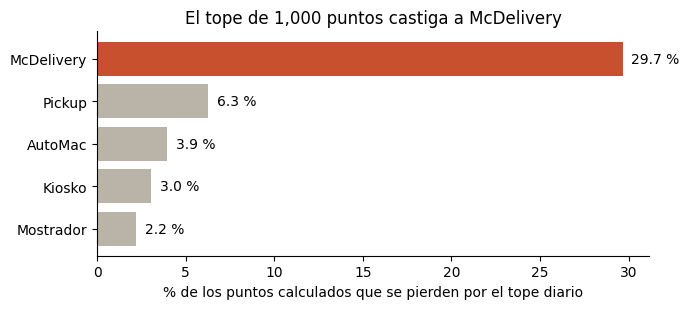

In [10]:
por_canal = (gold[~gold["canal"].isin(SIN_PUNTOS)]
             .groupby("canal")
             .agg(tickets=("ticket_id", "size"),
                  ticket_mediano=("total_q", "median"),
                  pct_sobre_Q100=("total_q", lambda x: 100 * (x > 100).mean()),
                  calculados=("puntos_calculados", "sum"),
                  perdidos=("perdidos_tope", "sum")))
por_canal["pct_perdido"] = 100 * por_canal["perdidos"] / por_canal["calculados"]
por_canal = por_canal.sort_values("pct_perdido")
display(por_canal.round(1))

fig, ax = plt.subplots(figsize=(7, 3.2))
colores = ["#C9502E" if c == "McDelivery" else "#B9B3A8" for c in por_canal.index]
ax.barh(por_canal.index, por_canal["pct_perdido"], color=colores)
for y, v in enumerate(por_canal["pct_perdido"]):
    ax.text(v + 0.5, y, f"{v:.1f} %", va="center")
ax.set_xlabel("% de los puntos calculados que se pierden por el tope diario")
ax.set_title("El tope de 1,000 puntos castiga a McDelivery")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretación:** con 10 puntos por quetzal, todo lo que se gaste arriba de Q100 en un día
ya no suma. Los canales del restaurante tienen tickets medianos de Q55–Q70 y casi no llegan
al tope, mientras que en McDelivery el ticket mediano ronda los Q125 y tres de cada cuatro
pedidos pasan de Q100. Por eso McDelivery pierde cerca del 30 % de sus puntos, varias veces
más que cualquier otro canal: el canal de los que **más gastan** es el **peor tratado**. En
el caso real fue 38.9 % contra ~17 % en caja; los porcentajes cambian porque esta
simulación es otra, pero el patrón es el mismo.

## 6. El saldo no se guarda: se calcula con un ledger

Como cada compra crea un **lote** que vence a los 365 días, un solo número de "saldo" no
alcanza: no dice qué parte vence cuándo. Por eso Gold arma un **libro de movimientos**
(*ledger*), como en contabilidad, y el saldo sale de procesarlo:

- Los puntos migrados del programa anterior (que manda el CRM) y cada compra con puntos son
  **abonos** que crean un lote.
- Cada canje es un **cargo** que consume primero el lote **más viejo** (FIFO), como en la
  refri, donde primero va lo que se va a arruinar.
- Antes de cada movimiento se **vencen** los lotes que cumplieron 365 días.

Esto no cabe en una consulta SQL: lo que vence de un lote depende de lo que consumieron los
canjes anteriores. En Databricks lo hicimos cliente por cliente con `applyInPandas`; aquí,
con un `groupby` de pandas.

In [11]:
migracion = (clientes.loc[clientes["migrados"] > 0, ["cliente", "migrados"]]
             .rename(columns={"migrados": "puntos"}).assign(fecha_hora=INICIO, tipo="migracion"))
abonos = gold.loc[gold["puntos_otorgados"] > 0, ["cliente", "fecha_hora", "puntos_otorgados"]]
abonos = abonos.rename(columns={"puntos_otorgados": "puntos"}).assign(tipo="compra")
cargos = canjes[["cliente", "fecha_hora", "costo"]].assign(puntos=lambda d: -d["costo"], tipo="canje")
ledger = (pd.concat([migracion, abonos, cargos.drop(columns="costo")], ignore_index=True)
          .sort_values(["cliente", "fecha_hora"]).reset_index(drop=True))
ledger["fecha"] = ledger["fecha_hora"].dt.normalize()
print(ledger["tipo"].value_counts().to_dict())


def procesar_lotes(mov):
    """Recorre el ledger de un cliente con lotes FIFO. Devuelve saldo, vencimientos y lotes vivos."""
    lotes = []                                  # [fecha_del_lote, puntos_restantes]
    vencimientos = []                           # (fecha en que venció, puntos)

    def vencer(hoy):
        for lote in lotes:
            if lote[1] > 0 and lote[0] + pd.Timedelta(days=DIAS_VENCE) <= hoy:
                vencimientos.append((lote[0] + pd.Timedelta(days=DIAS_VENCE), lote[1]))
                lote[1] = 0

    for fila in mov.itertuples():
        vencer(fila.fecha)
        if fila.puntos > 0:
            lotes.append([fila.fecha, fila.puntos])          # abono: nace un lote
        else:
            costo = -fila.puntos                             # canje: lo más viejo primero
            for lote in lotes:
                usar = min(lote[1], costo)
                lote[1] -= usar
                costo -= usar
    vencer(FIN)
    vivos = [(f, p) for f, p in lotes if p > 0]
    return sum(p for _, p in vivos), vencimientos, vivos


resultados = {c: procesar_lotes(m) for c, m in ledger.groupby("cliente")}
saldos = pd.DataFrame({c: {"saldo": r[0], "vencidos": sum(p for _, p in r[1])}
                       for c, r in resultados.items()}).T
saldos["perdidos_tope"] = gold.groupby("cliente")["perdidos_tope"].sum()
saldos = saldos.reindex(clientes["cliente"]).fillna(0).astype(int)
saldos.head()

{'compra': 19480, 'canje': 1724, 'migracion': 889}


,saldo,vencidos,perdidos_tope
cliente,,,
C00001,14446,6080,3700
C00002,12011,0,738
C00003,3709,0,1485
C00004,4257,2720,0
C00005,9698,1698,186


Así se ven los lotes vivos de un cliente al 20 de septiembre de 2026. Su saldo **no está
guardado en ningún lado**: es la suma de lo que queda en cada lote, y cada lote se puede
rastrear hasta la compra que lo originó.

In [12]:
con_vencidos = saldos[(saldos["vencidos"] > 0) & (saldos["saldo"] > 0)]
cliente_ej = con_vencidos["saldo"].sort_values().index[len(con_vencidos) // 2]
saldo_ej, vencimientos_ej, vivos_ej = resultados[cliente_ej]
vencidos_ej = sum(p for _, p in vencimientos_ej)
lotes_ej = pd.DataFrame(vivos_ej, columns=["fecha_del_lote", "puntos"])
lotes_ej["vence"] = lotes_ej["fecha_del_lote"] + pd.Timedelta(days=DIAS_VENCE)
print(f"Cliente {cliente_ej}: saldo {saldo_ej:,} = suma de {len(lotes_ej)} lotes vivos; "
      f"ya le vencieron {vencidos_ej:,} puntos")
lotes_ej.head(8)

Cliente C00692: saldo 6,611 = suma de 11 lotes vivos; ya le vencieron 853 puntos


,fecha_del_lote,puntos,vence
0,2025-10-15,462,2026-10-15
1,2025-10-16,406,2026-10-16
2,2025-12-23,570,2026-12-23
3,2025-12-30,651,2026-12-30
4,2026-01-30,423,2027-01-30
5,2026-02-16,674,2027-02-16
6,2026-04-19,503,2027-04-19
7,2026-05-07,860,2027-05-07


## 7. La prueba funcional (POC): pipeline contra hoja de respuestas

Llegó el momento de la verdad. El generador llevó su contabilidad en Python puro, con su
propia forma de aplicar el tope y los lotes; el pipeline la calculó desde los datos sucios.
Si las reglas están bien implementadas, **tienen que coincidir cliente por cliente**.

In [13]:
comparacion = saldos.join(hoja_respuestas, rsuffix="_hoja")
poc = pd.DataFrame([
    {"métrica": m,
     "total_pipeline": int(comparacion[m].sum()),
     "total_hoja": int(comparacion[f"{m}_hoja"].sum()),
     "clientes_con_diferencia": int((comparacion[m] != comparacion[f"{m}_hoja"]).sum())}
    for m in ["saldo", "vencidos", "perdidos_tope"]
])
poc

,métrica,total_pipeline,total_hoja,clientes_con_diferencia
0,saldo,8811509,8811509,0
1,vencidos,2250257,2250257,0
2,perdidos_tope,1770869,1770869,0


**Interpretación:** saldos, puntos vencidos y puntos perdidos por el tope coinciden en los
1,500 clientes, con 0 diferencias. Es la misma prueba que en el caso dio 0 de 5,150. Dos
implementaciones escritas por separado llegan al mismo resultado, y eso es mucho más
convincente que "el código corrió sin errores".

Y la prueba sirve de verdad: la primera vez que corrimos este notebook salió **1 cliente con
diferencia**. El error estaba en el generador, no en el pipeline: solo recorría a los
clientes con compras, y un cliente con puntos migrados que nunca compró quedó fuera de la
hoja de respuestas, aunque sus puntos sí vencían. Sin la comparación cliente por cliente,
ese error habría pasado desapercibido.

Un dato más que sale gratis del ledger: el **breakage**, los puntos que vencieron sin usarse,
y **cuándo** vencieron.

Migrados: 3,926,320 · acumulados por compras: 13,271,446 · vencidos: 2,250,257 (13.1 % de todo lo abonado)


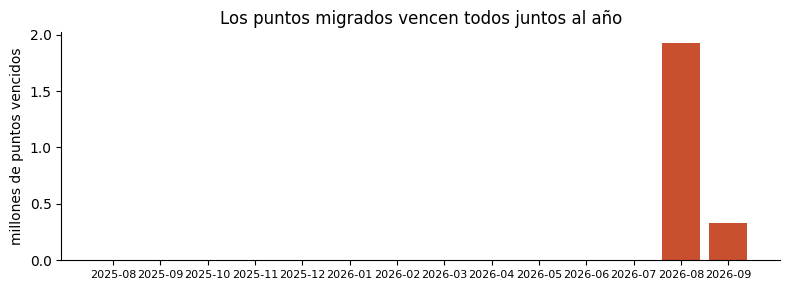

In [14]:
acumulados = int(gold["puntos_otorgados"].sum())
migrados_tot = int(clientes["migrados"].sum())
vencidos_tot = int(saldos["vencidos"].sum())
print(f"Migrados: {migrados_tot:,} · acumulados por compras: {acumulados:,} · "
      f"vencidos: {vencidos_tot:,} ({100 * vencidos_tot / (migrados_tot + acumulados):.1f} % de todo lo abonado)")

vencimientos = pd.DataFrame([v for r in resultados.values() for v in r[1]], columns=["fecha", "puntos"])
por_mes = (vencimientos.groupby(vencimientos["fecha"].dt.to_period("M"))["puntos"].sum()
           .reindex(pd.period_range(INICIO, FIN, freq="M"), fill_value=0))

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(por_mes.index.strftime("%Y-%m"), por_mes.values / 1e6, color="#C9502E")
ax.set_ylabel("millones de puntos vencidos")
ax.tick_params(axis="x", labelsize=8)
ax.set_title("Los puntos migrados vencen todos juntos al año")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretación:** se venció cerca del 13 % de todo lo abonado, y casi todo en **agosto de
2026**: son los puntos migrados del programa anterior, que entraron todos el día del
lanzamiento y vencen todos juntos un año después. Para la empresa es un pasivo que
desaparece; para sus clientes más antiguos, una mala experiencia. En el caso real el
breakage fue de 8.1 millones de puntos, el 44 % de lo acumulado por compras.

## 8. El recomendador de recompensas, con validación temporal

¿Qué recompensa le mostramos a cada cliente en la app? Primero el **baseline**: recomendar a
todos la categoría más canjeada. Después un modelo que usa los gustos que se ven en sus
compras. La métrica es **hit@1**: ¿la categoría recomendada es la que el cliente canjeó?

La **validación es temporal**, igual que en el caso: las variables se calculan con lo que pasó
**antes** de una fecha de corte y la etiqueta es lo que canjeó **después**. Mezclar el futuro
en las variables sería fuga de información, el mismo error del Ejercicio 1 con `score` y
`winner`.

In [15]:
def ventana(corte, hasta):
    """Variables con compras antes de `corte`; etiqueta = primer canje entre `corte` y `hasta`."""
    hist = silver[silver["fecha_hora"] < corte]
    X = pd.crosstab(hist["cliente"], hist["categoria"], normalize="index").reindex(columns=GUSTOS, fill_value=0)
    X["visitas"] = hist.groupby("cliente").size()
    futuros = canjes[(canjes["fecha_hora"] >= corte) & (canjes["fecha_hora"] < hasta)]
    y = futuros.sort_values("fecha_hora").groupby("cliente")["categoria"].first()
    comunes = X.index.intersection(y.index)
    return X.loc[comunes], y.loc[comunes]


X_tr, y_tr = ventana(pd.Timestamp("2026-03-20"), pd.Timestamp("2026-06-20"))
X_te, y_te = ventana(pd.Timestamp("2026-06-20"), FIN + pd.Timedelta(days=1))
print(f"Entrenamiento: {len(X_tr)} clientes (canjes de mar a jun) · "
      f"Prueba: {len(X_te)} clientes (canjes de jun a sep)")

popular = y_tr.mode()[0]
modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
modelo.fit(X_tr, y_tr)

pred = pd.Series(modelo.predict(X_te), index=X_te.index)
hit_popular = (y_te == popular).mean()
hit_modelo = (y_te == pred).mean()
print(f"Lo más popular ('{popular}'): hit@1 = {hit_popular:.3f}")
print(f"Modelo:                       hit@1 = {hit_modelo:.3f}  "
      f"({100 * (hit_modelo / hit_popular - 1):+.0f} %)")

Entrenamiento: 391 clientes (canjes de mar a jun) · Prueba: 362 clientes (canjes de jun a sep)
Lo más popular ('res'): hit@1 = 0.354
Modelo:                       hit@1 = 0.718  (+103 %)


Ahora por **gusto real** del cliente, que ninguno de los dos vio nunca:

In [16]:
gustos = clientes.set_index("cliente")["gusto"]
gusto_te, gusto_tr = gustos.loc[X_te.index], gustos.loc[X_tr.index]
segmentos = pd.DataFrame({
    "clientes": gusto_te.value_counts(),
    "hit@1 popular": (y_te == popular).groupby(gusto_te).mean(),
    "hit@1 modelo": (y_te == pred).groupby(gusto_te).mean(),
    "de su gusto (mar-jun)": (y_tr == gusto_tr).groupby(gusto_tr).mean(),
    "de su gusto (jun-sep)": (y_te == gusto_te).groupby(gusto_te).mean(),
}).reindex(GUSTOS)
segmentos.round(2)

,clientes,hit@1 popular,hit@1 modelo,de su gusto (mar-jun),de su gusto (jun-sep)
gusto,,,,,
desayuno,65,0.08,0.57,0.82,0.57
res,140,0.79,0.79,0.78,0.79
pollo,77,0.06,0.65,0.68,0.66
postre,80,0.10,0.79,0.78,0.82


**Interpretación:** "lo más popular" (res) solo le atina a quienes ya comen res; el modelo
aprende el gusto de cada cliente a partir de sus compras: empata en res y gana en los demás.
Aquí la ventaja es más grande que en el caso real (0.495 contra 0.356), porque en esta
simulación el gusto deja una huella muy clara en las compras.

Pero mira el segmento **desayuno** en las dos últimas columnas: de marzo a junio, 82 de cada
100 canjeaban algo de desayuno; de junio a septiembre, solo 57. El café salió del catálogo y
lo que queda de desayuno cuesta 5,000 o 7,500 puntos, así que muchos terminan canjeando algo
barato de otra categoría o no canjean nada. Por eso también es el segmento donde peor le va
al modelo. Ese problema no lo arregla ningún algoritmo: es del **catálogo**, y decidir qué
optimizar (lo que la gente canjea, más visitas o un ticket más alto) es una decisión de
negocio.

## Resumen

- Las **reglas** se escriben una vez, como código, y todo el pipeline las usa.
- Sin datos del cliente, los **datos sintéticos** con errores inyectados y **hoja de
  respuestas** permiten demostrar que el pipeline funciona.
- **Bronze** guarda la evidencia, **Silver** describe qué pasó (limpia y aparta en
  cuarentena con motivo) y **Gold** decide qué significa (aplica las reglas).
- Para validar la limpieza se comparan **registros**, no conteos: faltantes y falsas alarmas.
- El **tope diario** se calcula sin ciclos con una suma acumulada, y castiga a McDelivery.
- Como los puntos vencen por lote, el **saldo no se guarda, se calcula** con un ledger FIFO.
- La **POC** compara dos implementaciones independientes: 0 diferencias.
- En el recomendador: **baseline primero**, **validación temporal** y cuidado con lo que el
  modelo no puede arreglar.
- El orden del caso: primero **documentar**, después **medir** y hasta el final **ML**.